<H1>Importing the dataset</H1>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
df.shape

(1458644, 11)

In [5]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


In [7]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [8]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df=df.drop(columns=["id","dropoff_datetime"])

In [11]:
df

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...
1458639,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373


In [12]:
df["pickup_datetime"]=pd.to_datetime(df["pickup_datetime"])

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 9 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   vendor_id           1458644 non-null  int64         
 1   pickup_datetime     1458644 non-null  datetime64[us]
 2   passenger_count     1458644 non-null  int64         
 3   pickup_longitude    1458644 non-null  float64       
 4   pickup_latitude     1458644 non-null  float64       
 5   dropoff_longitude   1458644 non-null  float64       
 6   dropoff_latitude    1458644 non-null  float64       
 7   store_and_fwd_flag  1458644 non-null  str           
 8   trip_duration       1458644 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(3), str(1)
memory usage: 100.2 MB


In [14]:
df["pickup_hour"] = df["pickup_datetime"].dt.hour

In [15]:
df["pickup_day"] = df["pickup_datetime"].dt.day

In [16]:
df["pickup_month"] = df["pickup_datetime"].dt.month

In [17]:
df["pickup_weekday"] = df["pickup_datetime"].dt.weekday

In [18]:
df["pickup_year"] = df["pickup_datetime"].dt.year

In [19]:
df

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,pickup_year
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,3,0,2016
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6,6,2016
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1,1,2016
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,6,4,2,2016
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,26,3,5,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778,13,8,4,4,2016
1458640,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655,7,10,1,6,2016
1458641,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764,6,22,4,4,2016
1458642,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373,15,5,1,1,2016


In [20]:
df["pickup_year"].value_counts()

pickup_year
2016    1458644
Name: count, dtype: int64

In [21]:
df.drop("pickup_year", axis=1, inplace=True)

In [22]:
df

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,3,0
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6,6
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1,1
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,6,4,2
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,26,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778,13,8,4,4
1458640,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655,7,10,1,6
1458641,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764,6,22,4,4
1458642,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373,15,5,1,1


In [23]:
def get_time_of_day(hour):
    if 5<=hour<12:
        return "Morning"
    elif 12<=hour<17:
        return "Afternoon"
    elif 17<=hour<21:
        return "evening"
    else:
        return "Night"

In [24]:
df["time_of_day"] = df["pickup_hour"].apply(get_time_of_day)

In [25]:
df

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,time_of_day
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,3,0,evening
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6,6,Night
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1,1,Morning
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,6,4,2,evening
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,26,3,5,Afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778,13,8,4,4,Afternoon
1458640,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655,7,10,1,6,Morning
1458641,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764,6,22,4,4,Morning
1458642,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373,15,5,1,1,Afternoon


In [26]:
df["is_weekend"] = np.where(df["pickup_weekday"] >= 5,1,0)

In [27]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,time_of_day,is_weekend
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,3,0,evening,0
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6,6,Night,1
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1,1,Morning,0
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,6,4,2,evening,0
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,26,3,5,Afternoon,1


<h1>Earth is round, we'll use the Haversine Formula for calculating the distance</h1>

In [28]:
from math import radians, sin, cos, sqrt, asin
def haversine(lat1,long1,lat2,long2):
    lat1 = radians(lat1)
    lat2 = radians(lat2)
    long1 = radians(long1)
    long2 = radians(long2)
    #differnce 
    dlat = lat2 - lat1
    dlon = long2 - long1
    #haversine calculation
    a = sin(dlat/2)**2+cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2*asin(sqrt(a))
    #radius of earth in kilometer
    R=6371
    return R*c

In [29]:
df["distance"] = df.apply(
    lambda row: haversine(
        row["pickup_latitude"],
        row["pickup_longitude"],
        row["dropoff_latitude"],
        row["dropoff_longitude"]),axis=1)

In [30]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,time_of_day,is_weekend,distance
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,3,0,evening,0,1.498521
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6,6,Night,1,1.805507
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1,1,Morning,0,6.385098
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,6,4,2,evening,0,1.485498
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,26,3,5,Afternoon,1,1.188588


In [31]:
df["is_peak_hour"] = np.where(
    ((df["pickup_hour"] >= 7) & (df["pickup_hour"] <= 10)) |
    ((df["pickup_hour"] >= 16) & (df["pickup_hour"] <= 19)),
    1,
    0
)

<h1>EDA on Enginnered Features</h1>

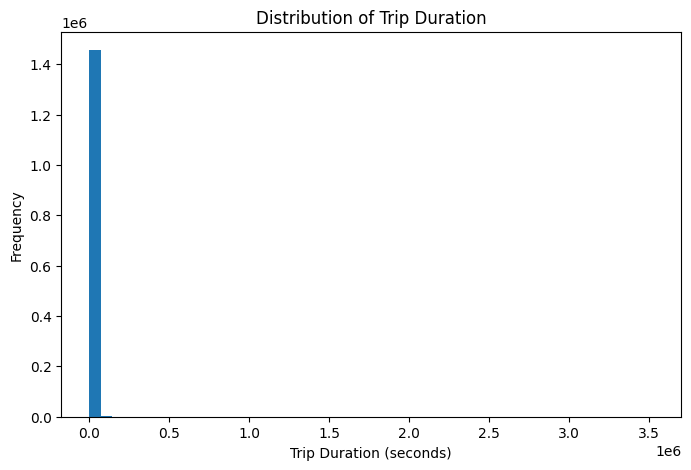

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["trip_duration"],bins=50)
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Trip Duration")
plt.show()

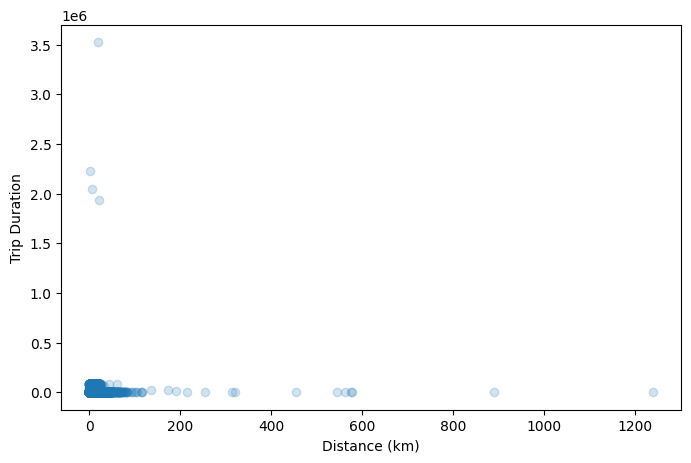

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["distance"],
    df["trip_duration"],
    alpha=0.2
)

plt.xlabel("Distance (km)")
plt.ylabel("Trip Duration")
plt.show()

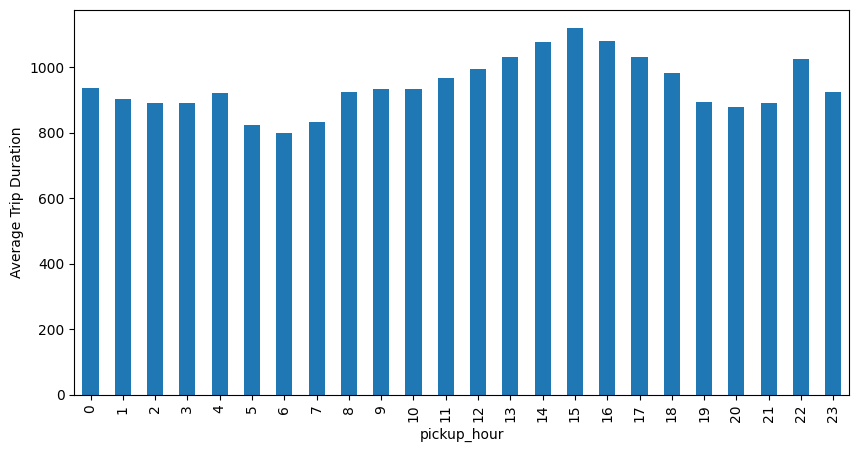

In [34]:
hourly = (
    df.groupby("pickup_hour")["trip_duration"]
      .mean()
)

hourly.plot(kind="bar", figsize=(10,5))
plt.ylabel("Average Trip Duration")
plt.show()

In [35]:
df["distance"].describe()

count    1.458644e+06
mean     3.440864e+00
std      4.296538e+00
min      0.000000e+00
25%      1.231837e+00
50%      2.093717e+00
75%      3.875337e+00
max      1.240909e+03
Name: distance, dtype: float64

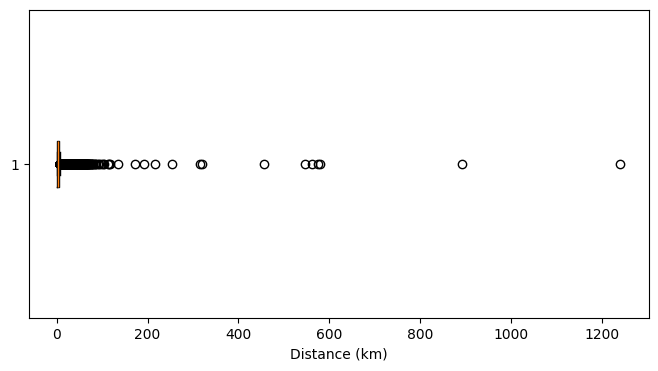

In [36]:
plt.figure(figsize=(8,4))
plt.boxplot(df["distance"], vert=False)
plt.xlabel("Distance (km)")
plt.show()

In [37]:
df[df["distance"]>100]

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,time_of_day,is_weekend,distance,is_peak_hour
14502,1,2016-04-15 22:35:08,1,-73.781792,40.644718,-72.711395,41.311520,N,7153,22,15,4,4,Night,0,116.496424,0
114376,1,2016-02-29 12:16:29,3,-75.455917,39.803932,-73.796021,40.707726,N,23440,12,29,2,0,Afternoon,0,173.029358,0
184925,1,2016-05-07 18:58:53,1,-72.809669,51.881084,-73.987228,40.750599,N,792,18,7,5,5,evening,1,1240.908677,1
275644,1,2016-02-24 16:20:59,4,-75.354332,34.712234,-73.834923,32.181141,N,875,16,24,2,2,Afternoon,0,314.764203,1
283102,2,2016-01-17 16:43:09,1,-73.997086,40.728924,-72.671150,40.614220,N,427,16,17,1,6,Afternoon,1,112.548872,1
377068,1,2016-04-02 20:33:19,1,-74.007095,40.717113,-76.963242,38.946033,N,282,20,2,4,5,evening,1,320.125775,0
397526,1,2016-04-28 13:32:14,2,-73.870682,40.773598,-79.817978,38.963852,N,2515,13,28,4,3,Afternoon,0,545.853499,0
512980,1,2016-01-25 23:53:17,1,-73.877716,40.772167,-72.905891,41.319832,N,5549,23,25,1,0,Night,0,101.736296,0
595540,1,2016-03-20 21:07:56,1,-78.547401,40.817131,-79.786133,40.917637,N,279,21,20,3,6,Night,1,104.759971,0
644165,2,2016-06-02 15:19:35,1,-73.980751,40.757111,-74.240051,38.478298,N,804,15,2,6,3,Afternoon,0,254.363523,0


In [38]:
df[df["distance"]>100].shape

(19, 17)

In [39]:
df = df[df["distance"] <= 100]

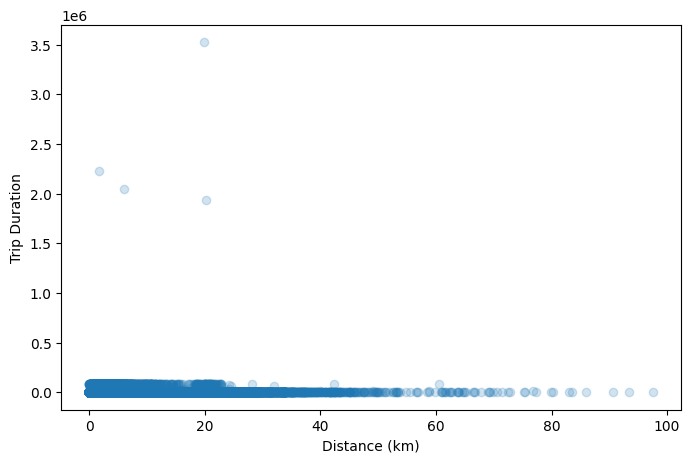

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["distance"],
    df["trip_duration"],
    alpha=0.2
)

plt.xlabel("Distance (km)")
plt.ylabel("Trip Duration")
plt.show()

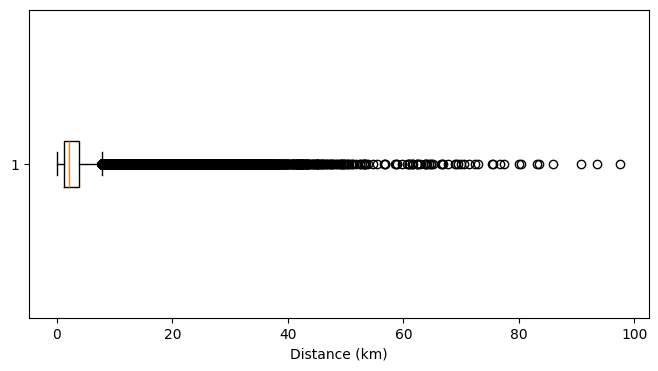

In [41]:
plt.figure(figsize=(8,4))
plt.boxplot(df["distance"], vert=False)
plt.xlabel("Distance (km)")
plt.show()

In [42]:
df["trip_duration"].describe()

count    1.458625e+06
mean     9.594479e+02
std      5.237404e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

In [43]:
df[df["trip_duration"] > 100000]

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,time_of_day,is_weekend,distance,is_peak_hour
355003,1,2016-01-05 00:19:42,1,-73.789650,40.643559,-73.956810,40.773087,N,1939736,0,5,1,1,Night,0,20.148664,0
680594,1,2016-02-13 22:38:00,2,-73.921677,40.735252,-73.984749,40.759979,N,2049578,22,13,2,5,Night,1,5.982487,0
924150,1,2016-01-05 06:14:15,1,-73.983788,40.742325,-73.985489,40.727676,N,2227612,6,5,1,1,Morning,0,1.635128,0
978383,1,2016-02-13 22:46:52,1,-73.783905,40.648632,-73.978271,40.750202,N,3526282,22,13,2,5,Night,1,19.900661,0


In [44]:
df[df["trip_duration"] > 100000].shape

(4, 17)

In [45]:
df = df[df["trip_duration"] <= 100000]

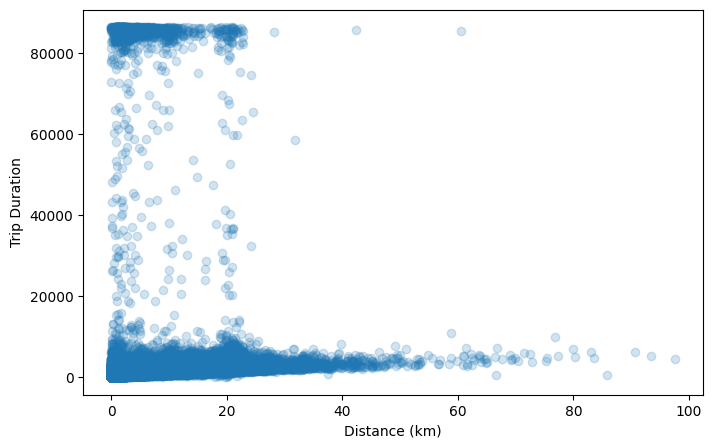

In [46]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["distance"],
    df["trip_duration"],
    alpha=0.2
)

plt.xlabel("Distance (km)")
plt.ylabel("Trip Duration")
plt.show()

<h1>Target cleaning</h1>

In [47]:
df["trip_duration"].describe()

count    1.458621e+06
mean     9.527708e+02
std      3.171240e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      8.639200e+04
Name: trip_duration, dtype: float64

In [48]:
df["trip_duration"].quantile([0.95, 0.99, 0.999])

0.950     2104.00
0.990     3439.00
0.999    85120.42
Name: trip_duration, dtype: float64

In [49]:
df[df["trip_duration"] > 4000].shape

(8284, 17)

In [50]:
df["speed_kmph"] = df["distance"] / (df["trip_duration"] / 3600)

In [51]:
df

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,time_of_day,is_weekend,distance,is_peak_hour,speed_kmph
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,3,0,evening,0,1.498521,1,11.856428
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6,6,Night,1,1.805507,0,9.803659
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1,1,Morning,0,6.385098,0,10.822201
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,6,4,2,evening,0,1.485498,1,12.465721
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,26,3,5,Afternoon,1,1.188588,0,9.836594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778,13,8,4,4,Afternoon,0,1.225080,0,5.668751
1458640,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655,7,10,1,6,Morning,1,6.049836,1,33.251005
1458641,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764,6,22,4,4,Morning,0,7.824606,0,36.869870
1458642,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373,15,5,1,1,Afternoon,0,1.092564,0,10.544853


In [52]:
df["speed_kmph"].describe()

count    1.458621e+06
mean     1.440136e+01
std      1.148457e+01
min      0.000000e+00
25%      9.121264e+00
50%      1.279194e+01
75%      1.784461e+01
max      9.274837e+03
Name: speed_kmph, dtype: float64

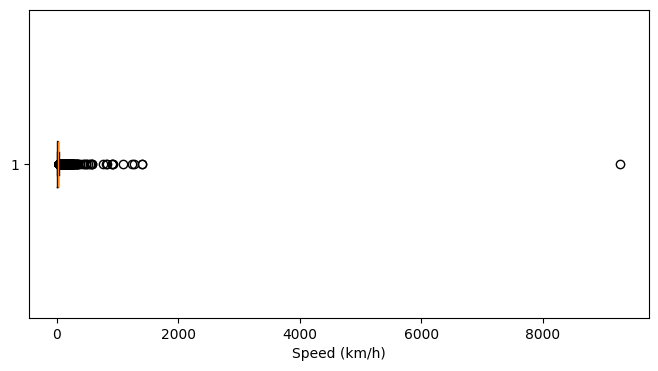

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(df["speed_kmph"], vert=False)
plt.xlabel("Speed (km/h)")
plt.show()

In [54]:
df[df["speed_kmph"] > 120]

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,time_of_day,is_weekend,distance,is_peak_hour,speed_kmph
1107,2,2016-06-23 13:36:48,3,-73.827660,40.716175,-73.822113,40.711452,N,2,13,23,6,3,Afternoon,0,0.703065,0,1265.516683
12527,2,2016-05-15 18:31:33,5,-73.791206,40.666481,-73.800903,40.669819,N,26,18,15,5,6,evening,1,0.898129,1,124.356287
13046,1,2016-06-27 18:37:21,1,-73.881195,40.882942,-73.965141,40.762486,N,355,18,27,6,0,evening,0,15.142631,1,153.559078
25397,2,2016-03-27 16:28:42,1,-74.069908,40.739052,-74.157913,40.712528,N,223,16,27,3,6,Afternoon,1,7.980951,1,128.840458
39020,2,2016-01-18 18:19:50,1,-74.393555,40.785603,-74.398514,40.781822,N,16,18,18,1,0,evening,0,0.592479,1,133.307874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359910,1,2016-05-05 18:21:37,1,-79.569733,41.586273,-80.355431,42.090183,N,548,18,5,5,3,evening,0,85.884876,1,564.207216
1370617,2,2016-02-07 15:00:04,1,-73.983749,40.755661,-73.981155,40.753223,N,7,15,7,2,6,Afternoon,1,0.348149,0,179.048050
1390507,2,2016-05-06 18:29:00,1,-73.874718,40.730610,-73.867432,40.732868,N,5,18,6,5,4,evening,0,0.663298,1,477.574860
1398157,2,2016-03-05 00:17:29,1,-74.003487,40.732609,-74.004189,40.731274,N,3,0,5,3,5,Night,1,0.159808,0,191.769583


In [55]:
df[df["speed_kmph"] < 1]

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,time_of_day,is_weekend,distance,is_peak_hour,speed_kmph
246,2,2016-02-29 18:39:12,1,-73.981819,40.768963,-73.981819,40.768963,N,227,18,29,2,0,evening,0,0.000000,1,0.000000
291,2,2016-05-10 18:07:52,2,-73.959068,40.775661,-73.959068,40.775661,N,1109,18,10,5,1,evening,0,0.000000,1,0.000000
323,1,2016-06-27 11:22:37,1,-74.001030,40.756653,-74.000999,40.756626,N,40,11,27,6,0,Morning,0,0.003927,0,0.353456
337,1,2016-05-20 14:04:03,1,-73.986305,40.777023,-73.985855,40.776791,N,1778,14,20,5,4,Afternoon,0,0.045892,0,0.092921
407,2,2016-05-16 23:15:13,6,-73.808487,40.687336,-73.808487,40.687336,N,947,23,16,5,0,Night,0,0.000000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457746,2,2016-01-29 21:58:11,1,-73.975708,40.733089,-73.975685,40.733101,N,12,21,29,1,4,Night,0,0.002311,0,0.693159
1457752,2,2016-02-02 11:31:10,6,-73.972069,40.794220,-73.961014,40.806728,N,86314,11,2,2,1,Morning,0,1.673445,0,0.069796
1458044,2,2016-03-12 01:35:35,1,-74.007378,40.739441,-74.007378,40.739449,N,7,1,12,3,5,Night,1,0.000848,0,0.436294
1458076,2,2016-04-24 00:58:34,1,-73.990479,40.760876,-73.983025,40.764557,N,86262,0,24,4,6,Night,1,0.749437,0,0.031277


In [56]:
df[df["speed_kmph"] > 120].shape

(123, 18)

In [57]:
df[df["speed_kmph"] > 120][
    ["distance", "trip_duration", "speed_kmph"]
].head(10)

,distance,trip_duration,speed_kmph
1107,0.703065,2,1265.516683
12527,0.898129,26,124.356287
13046,15.142631,355,153.559078
25397,7.980951,223,128.840458
39020,0.592479,16,133.307874
87582,0.439629,11,143.878472
107171,1.147109,16,258.099434
125668,12.040846,265,163.573763
127613,0.435466,9,174.186529
133641,1.271745,8,572.285162


In [58]:
df = df[df["speed_kmph"] <= 120]

In [59]:
df[df["speed_kmph"] < 1].shape

(13236, 18)

In [60]:
df[df["speed_kmph"] < 1][
    ["distance", "trip_duration", "speed_kmph"]
].head(20)

,distance,trip_duration,speed_kmph
246,0.000000,227,0.000000
291,0.000000,1109,0.000000
323,0.003927,40,0.353456
337,0.045892,1778,0.092921
407,0.000000,947,0.000000
531,2.992817,84594,0.127363
552,0.044322,1905,0.083757
702,0.000000,580,0.000000
850,0.026000,686,0.136442
1134,1.176094,86149,0.049147


In [61]:
df[df["speed_kmph"] == 0].shape

(5897, 18)

In [62]:
df = df[df["speed_kmph"] > 0]

In [63]:
df[df["speed_kmph"] < 1].shape

(7339, 18)

In [64]:
df[df["speed_kmph"] < 1][
    ["distance", "trip_duration", "speed_kmph"]
].head(20)

,distance,trip_duration,speed_kmph
323,0.003927,40,0.353456
337,0.045892,1778,0.092921
531,2.992817,84594,0.127363
552,0.044322,1905,0.083757
850,0.026000,686,0.136442
1134,1.176094,86149,0.049147
1182,0.005973,41,0.524471
1334,0.002869,40,0.258170
1378,0.034561,4107,0.030295
1418,0.015222,2896,0.018922


In [65]:
df = df[
    ~(
        (df["distance"] > 1) &
        (df["trip_duration"] > 20000)
    )
]

In [66]:
print(df.columns.tolist())

['vendor_id', 'pickup_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'time_of_day', 'is_weekend', 'distance', 'is_peak_hour', 'speed_kmph']


In [67]:
df.head(5)

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,time_of_day,is_weekend,distance,is_peak_hour,speed_kmph
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,14,3,0,evening,0,1.498521,1,11.856428
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,12,6,6,Night,1,1.805507,0,9.803659
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,19,1,1,Morning,0,6.385098,0,10.822201
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,6,4,2,evening,0,1.485498,1,12.465721
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,26,3,5,Afternoon,1,1.188588,0,9.836594


In [68]:
df.drop(columns=["pickup_datetime"], inplace=True)

In [69]:
df.drop(columns=["speed_kmph"], inplace=True)

In [70]:
df.dtypes

vendor_id               int64
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag        str
trip_duration           int64
pickup_hour             int32
pickup_day              int32
pickup_month            int32
pickup_weekday          int32
time_of_day               str
is_weekend              int64
distance              float64
is_peak_hour            int64
dtype: object

In [71]:
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].map({
    "N": 0,
    "Y": 1
})

In [72]:
df = pd.get_dummies(
    df,
    columns=["time_of_day"],
    drop_first=True
)

In [73]:
X = df.drop(columns=["trip_duration"])
y = df["trip_duration"]

In [74]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state= 42)

In [75]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1160677, 17)
(290170, 17)
(1160677,)
(290170,)


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [77]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
y_pred = model.predict(X_test_scaled)

In [79]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 297.89
MSE  : 1728068.72
RMSE : 1314.56
R²   : 0.1290


In [80]:
import sklearn
print(sklearn.__version__)

1.7.1


In [81]:
print(X.columns.tolist())

['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'is_weekend', 'distance', 'is_peak_hour', 'time_of_day_Morning', 'time_of_day_Night', 'time_of_day_evening']


In [82]:
df

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,is_weekend,distance,is_peak_hour,time_of_day_Morning,time_of_day_Night,time_of_day_evening
0,2,1,-73.982155,40.767937,-73.964630,40.765602,0,455,17,14,3,0,0,1.498521,1,False,False,True
1,1,1,-73.980415,40.738564,-73.999481,40.731152,0,663,0,12,6,6,1,1.805507,0,False,True,False
2,2,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,11,19,1,1,0,6.385098,0,True,False,False
3,2,1,-74.010040,40.719971,-74.012268,40.706718,0,429,19,6,4,2,0,1.485498,1,False,False,True
4,2,1,-73.973053,40.793209,-73.972923,40.782520,0,435,13,26,3,5,1,1.188588,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,2,4,-73.982201,40.745522,-73.994911,40.740170,0,778,13,8,4,4,0,1.225080,0,False,False,False
1458640,1,1,-74.000946,40.747379,-73.970184,40.796547,0,655,7,10,1,6,1,6.049836,1,True,False,False
1458641,2,1,-73.959129,40.768799,-74.004433,40.707371,0,764,6,22,4,4,0,7.824606,0,True,False,False
1458642,1,1,-73.982079,40.749062,-73.974632,40.757107,0,373,15,5,1,1,0,1.092564,0,False,False,False


In [83]:
dummy_cols = [col for col in df.columns if col.startswith("time_of_day_")]

df[dummy_cols] = df[dummy_cols].astype(int)

In [84]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [85]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_tree)
rmse = root_mean_squared_error(y_test, y_pred_tree)
r2 = r2_score(y_test, y_pred_tree)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 298.78
RMSE : 1739.42
R²   : -0.5250


In [86]:
print("Train R²:", tree.score(X_train, y_train))
print("Test R² :", tree.score(X_test, y_test))

Train R²: 1.0
Test R² : -0.5250105467773063


In [87]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [88]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_tree)
rmse = root_mean_squared_error(y_test, y_pred_tree)
r2 = r2_score(y_test, y_pred_tree)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 249.60
RMSE : 1300.66
R²   : 0.1473


In [89]:
import numpy as np

y = np.log1p(df["trip_duration"])

In [90]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [91]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", root_mean_squared_error(y_test, y_pred_rf))
print("R²  :", r2_score(y_test, y_pred_rf))

MAE : 226.06596779678344
RMSE: 1291.4502848487887
R²  : 0.1593401717935321


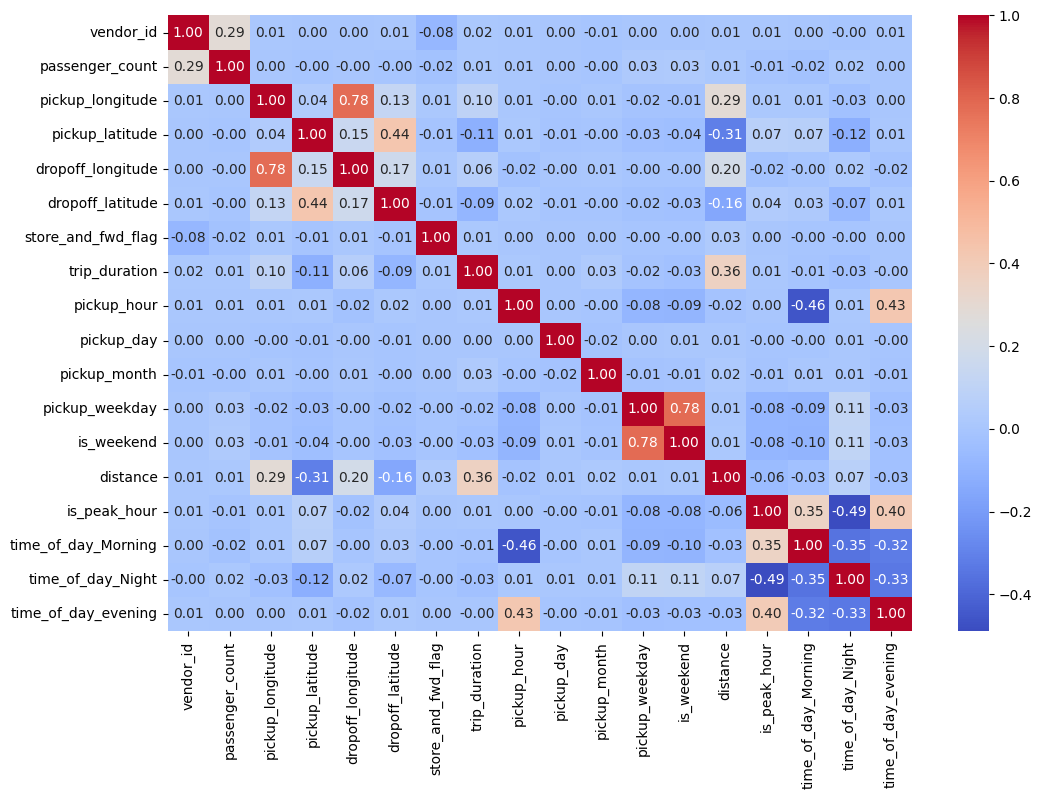

In [92]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [93]:
df[["distance", "trip_duration"]].describe()

,distance,trip_duration
count,1.450847e+06,1.450847e+06
mean,3.448232e+00,8.557921e+02
std,3.943127e+00,1.366481e+03
min,4.241750e-04,1.000000e+00
25%,1.240087e+00,3.980000e+02
50%,2.101931e+00,6.630000e+02
75%,3.886305e+00,1.074000e+03
max,9.758621e+01,8.636700e+04


In [94]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

                Feature  Importance
12             distance    0.695611
7           pickup_hour    0.057175
5      dropoff_latitude    0.051684
4     dropoff_longitude    0.040485
2      pickup_longitude    0.040328
3       pickup_latitude    0.036490
10       pickup_weekday    0.018348
15    time_of_day_Night    0.016566
8            pickup_day    0.011679
9          pickup_month    0.011517
11           is_weekend    0.008575
1       passenger_count    0.003868
14  time_of_day_Morning    0.002613
0             vendor_id    0.002496
13         is_peak_hour    0.001955
16  time_of_day_evening    0.000597
6    store_and_fwd_flag    0.000013


In [95]:
df[df["trip_duration"] > 20000][
    ["distance", "trip_duration"]
].describe()

,distance,trip_duration
count,306.000000,306.000000
mean,0.660358,82305.620915
std,0.263148,11887.075146
min,0.000643,20129.000000
25%,0.537383,85203.750000
50%,0.720340,85981.000000
75%,0.863021,86216.750000
max,0.998016,86367.000000


In [96]:
df[df["trip_duration"] > 20000].shape

(306, 18)

In [97]:
df = df[df["trip_duration"] <= 20000]

In [98]:
y = np.log1p(df["trip_duration"])

In [100]:
df

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday,is_weekend,distance,is_peak_hour,time_of_day_Morning,time_of_day_Night,time_of_day_evening
0,2,1,-73.982155,40.767937,-73.964630,40.765602,0,455,17,14,3,0,0,1.498521,1,0,0,1
1,1,1,-73.980415,40.738564,-73.999481,40.731152,0,663,0,12,6,6,1,1.805507,0,0,1,0
2,2,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,11,19,1,1,0,6.385098,0,1,0,0
3,2,1,-74.010040,40.719971,-74.012268,40.706718,0,429,19,6,4,2,0,1.485498,1,0,0,1
4,2,1,-73.973053,40.793209,-73.972923,40.782520,0,435,13,26,3,5,1,1.188588,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,2,4,-73.982201,40.745522,-73.994911,40.740170,0,778,13,8,4,4,0,1.225080,0,0,0,0
1458640,1,1,-74.000946,40.747379,-73.970184,40.796547,0,655,7,10,1,6,1,6.049836,1,1,0,0
1458641,2,1,-73.959129,40.768799,-74.004433,40.707371,0,764,6,22,4,4,0,7.824606,0,1,0,0
1458642,1,1,-73.982079,40.749062,-73.974632,40.757107,0,373,15,5,1,1,0,1.092564,0,0,0,0


In [101]:
import numpy as np

y = np.log1p(df["trip_duration"])

In [104]:
print(y_pred_log[:10])

[ 474.89770824  550.95526026  928.84901289  720.32795283  627.1599438
  657.68516211 1587.6068088  1302.09431576  517.67762046  412.74462024]


In [105]:
print(y_pred_log.min())
print(y_pred_log.max())

13.080444132975318
7083.404732164199


In [106]:
print(y_train.min())
print(y_train.max())

1
86367


In [108]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [110]:
y_pred_log = rf.predict(X_test)

In [111]:
import numpy as np

X = df.drop("trip_duration", axis=1)
y = np.log1p(df["trip_duration"])

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [113]:
print(y_train.min())
print(y_train.max())

0.6931471805599453
9.841346155998279


In [114]:
from sklearn.ensemble import RandomForestRegressor

rf_log = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_log.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
y_pred_log = rf_log.predict(X_test)

print(y_pred_log.min())
print(y_pred_log.max())

2.2399458656250557
8.519453002482702


In [116]:
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

In [117]:
print(y_train.min())
print(y_train.max())

print(y_pred_log.min())
print(y_pred_log.max())

0.6931471805599453
9.841346155998279
2.2399458656250557
8.519453002482702


In [118]:
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

In [119]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test_original, y_pred)
rmse = root_mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 191.15
RMSE : 318.97
R²   : 0.7674


In [120]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_log.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

                Feature  Importance
12             distance    0.827450
7           pickup_hour    0.050027
5      dropoff_latitude    0.039777
4     dropoff_longitude    0.018302
2      pickup_longitude    0.017009
10       pickup_weekday    0.015535
3       pickup_latitude    0.012841
11           is_weekend    0.004827
9          pickup_month    0.003428
15    time_of_day_Night    0.003231
8            pickup_day    0.003163
13         is_peak_hour    0.001289
14  time_of_day_Morning    0.001287
1       passenger_count    0.000947
0             vendor_id    0.000632
16  time_of_day_evening    0.000247
6    store_and_fwd_flag    0.000007


In [121]:
cols_to_drop = [
    "store_and_fwd_flag",
    "vendor_id",
    "time_of_day_evening",
    "passenger_count"
]

df = df.drop(columns=cols_to_drop)

In [122]:
X = df.drop("trip_duration", axis=1)
y = np.log1p(df["trip_duration"])

In [123]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [124]:
from sklearn.ensemble import RandomForestRegressor

rf_new = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

In [125]:
rf_new.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [126]:
y_pred_log = rf_new.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

In [127]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

print("MAE :", mean_absolute_error(y_test_original, y_pred))
print("RMSE:", root_mean_squared_error(y_test_original, y_pred))
print("R²  :", r2_score(y_test_original, y_pred))

MAE : 191.10758956449035
RMSE: 318.94355574652593
R²  : 0.7674482303607199


In [128]:
import joblib

joblib.dump(rf_new, "taxi_trip_duration_model.pkl")

['taxi_trip_duration_model.pkl']

In [129]:
joblib.dump(list(X.columns), "feature_columns.pkl")

['feature_columns.pkl']

In [130]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'feature_columns.pkl', 'taxi_trip_duration_model.pkl', 'test.csv', 'train.csv', 'Untitled.ipynb']


In [131]:
print(X.columns.tolist())

['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'is_weekend', 'distance', 'is_peak_hour', 'time_of_day_Morning', 'time_of_day_Night']
